<a href="https://colab.research.google.com/github/rikharhm0208-coder/PROJECT_KOMPUTASI_KEUANGAN/blob/main/SIMULASI_FTCS_BTCS_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Simulasi Penyelesaian Persamaan Panas dengan Metode FTCS, BTCS, dan Crank Nicolson dan Perbandingannya dengan Solusi Analitik**

=== SKENARIO STABLE (Lambda = 0.40) ===
  x     Analitik         FTCS         BTCS           CN
0.0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
0.1 1.151731e-01 1.148447e-01 1.159643e-01 1.154059e-01
0.2 2.190722e-01 2.184476e-01 2.205772e-01 2.195151e-01
0.3 3.015270e-01 3.006674e-01 3.035985e-01 3.021366e-01
0.4 3.544662e-01 3.534557e-01 3.569014e-01 3.551829e-01
0.5 3.727078e-01 3.716453e-01 3.752684e-01 3.734614e-01
0.6 3.544662e-01 3.534557e-01 3.569014e-01 3.551829e-01
0.7 3.015270e-01 3.006674e-01 3.035985e-01 3.021366e-01
0.8 2.190722e-01 2.184476e-01 2.205772e-01 2.195151e-01
0.9 1.151731e-01 1.148447e-01 1.159643e-01 1.154059e-01
1.0 4.564355e-17 1.224647e-16 1.224647e-16 1.224647e-16

=== SKENARIO UNSTABLE (Lambda = 2.00) ===
  x     Analitik         FTCS         BTCS           CN
0.0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
0.1 1.151731e-01 2.542758e-01 1.181492e-01 1.153838e-01
0.2 2.190722e-01 4.798398e-01 2.247331e-01 2.194731e-01
0.3 3.015270e-01 5.72

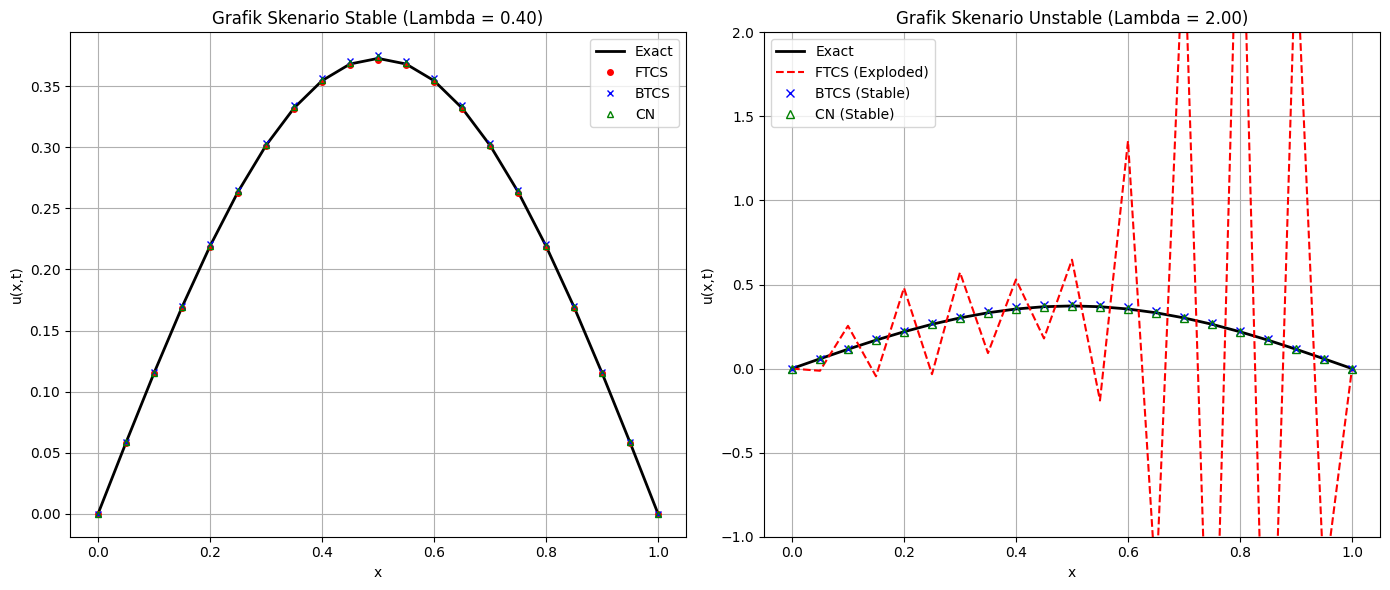


RMS Error (Stable):
FTCS : 7.332028e-04
BTCS : 1.766921e-03
CN   : 5.199838e-04

RMS Error (Unstable):
FTCS : 1.482887e+00
BTCS : 6.645936e-03
CN   : 4.707222e-04


In [13]:
#===============================================================================
#   SIMULATION OF FTCS, BTCS, AND CRANK NICOLSON
#   HEAT EQUATION U_t = U_xx
#===============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ==============================================================================
# 1. KONFIGURASI PARAMETER GLOBAL
# ==============================================================================
alpha = 1.0     # u_t = u_xx
L = 1.0         # Domain ruang [0, 1]
T = 0.1         # Domain waktu
nx = 21         # Jumlah titik ruang
h = L / (nx - 1)
x = np.linspace(0, L, nx)

# Kondisi Awal: u(x,0) = sin(pi * x)
u_awal = np.sin(np.pi * x)

# Solusi Eksak (Analitik)
def exact_sol(x, t):
    return np.exp(-(np.pi**2) * t) * np.sin(np.pi * x)

# ==============================================================================
# 2. FUNGSI INTI SIMULASI
# ==============================================================================
def jalankan_simulasi(nt_langkah):
    dt = T / nt_langkah
    lmbda = alpha * dt / (h**2)

    # Inisialisasi
    u_f = u_awal.copy()
    u_b = u_awal.copy()
    u_c = u_awal.copy()

    # --- FTCS ---
    for _ in range(nt_langkah):
        u_next = u_f.copy()
        u_next[1:-1] = lmbda*u_f[:-2] + (1 - 2*lmbda)*u_f[1:-1] + lmbda*u_f[2:]
        u_f = u_next

    # --- BTCS ---
    A_btcs = np.zeros((3, nx-2))
    A_btcs[0, 1:] = -lmbda
    A_btcs[1, :] = 1 + 2*lmbda
    A_btcs[2, :-1] = -lmbda
    for _ in range(nt_langkah):
        u_b[1:-1] = solve_banded((1, 1), A_btcs, u_b[1:-1])

    # --- Crank-Nicolson ---
    A_cn = np.zeros((3, nx-2))
    A_cn[0, 1:] = -lmbda/2
    A_cn[1, :] = 1 + lmbda
    A_cn[2, :-1] = -lmbda/2
    for _ in range(nt_langkah):
        rhs = (lmbda/2)*u_c[:-2] + (1 - lmbda)*u_c[1:-1] + (lmbda/2)*u_c[2:]
        u_c[1:-1] = solve_banded((1, 1), A_cn, rhs)

    return u_f, u_b, u_c, lmbda

# ==============================================================================
# 3. EKSEKUSI SKENARIO
# ==============================================================================

# --- SKENARIO 1: STABIL (nt = 100, Lambda = 0.4) ---
u_f_s, u_b_s, u_c_s, lam_s = jalankan_simulasi(100)
u_true = exact_sol(x, T)

# --- SKENARIO 2: UNSTABLE (nt = 20, Lambda = 2.0) ---
u_f_u, u_b_u, u_c_u, lam_u = jalankan_simulasi(20)

# ===============================================================================
# 4. OUTPUT TABEL PERBANDINGAN
# ===============================================================================

print(f"=== SKENARIO STABLE (Lambda = {lam_s:.2f}) ===")
df_s = pd.DataFrame({'x': x, 'Analitik': u_true, 'FTCS': u_f_s, 'BTCS': u_b_s, 'CN': u_c_s})
print(df_s.iloc[::2].to_string(index=False)) # Tampilkan sampel titik

print(f"\n=== SKENARIO UNSTABLE (Lambda = {lam_u:.2f}) ===")
df_u = pd.DataFrame({'x': x, 'Analitik': u_true, 'FTCS': u_f_u, 'BTCS': u_b_u, 'CN': u_c_u})
print(df_u.iloc[::2].to_string(index=False))

# ==============================================================================
# 5. VISUALISASI GRAFIK
# ==============================================================================
plt.figure(figsize=(14, 6))

# Plot Grafik Stabil
plt.subplot(1, 2, 1)
plt.plot(x, u_true, 'k-', label='Exact', linewidth=2)
plt.plot(x, u_f_s, 'ro', label='FTCS', markersize=4)
plt.plot(x, u_b_s, 'bx', label='BTCS', markersize=4)
plt.plot(x, u_c_s, 'g^', label='CN', markersize=4, fillstyle='none')
plt.title(f'Grafik Skenario Stable (Lambda = {lam_s:.2f})')
plt.xlabel('x'); plt.ylabel('u(x,t)'); plt.legend(); plt.grid(True)

# Plot Grafik Unstable
plt.subplot(1, 2, 2)
plt.plot(x, u_true, 'k-', label='Exact', linewidth=2)
plt.plot(x, u_f_u, 'r--', label='FTCS (Exploded)')
plt.plot(x, u_b_u, 'bx', label='BTCS (Stable)')
plt.plot(x, u_c_u, 'g^', label='CN (Stable)', fillstyle='none')
plt.title(f'Grafik Skenario Unstable (Lambda = {lam_u:.2f})')
plt.xlabel('x'); plt.ylabel('u(x,t)'); plt.legend(); plt.grid(True)
plt.ylim(-1, 2) # Batasi y agar ledakan FTCS terlihat jelas

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. OUTPUT TABEL PERBANDINGAN & ERROR
# ==============================================================================

def hitung_rmse(numerik, analitik):
    return np.sqrt(np.mean((numerik - analitik)**2))

print("\nRMS Error (Stable):")
print(f"FTCS : {hitung_rmse(u_f_s, u_true):.6e}")
print(f"BTCS : {hitung_rmse(u_b_s, u_true):.6e}")
print(f"CN   : {hitung_rmse(u_c_s, u_true):.6e}")

print("\nRMS Error (Unstable):")
# Catatan: FTCS akan menghasilkan error yang sangat besar (atau NaN) karena meledak
print(f"FTCS : {hitung_rmse(u_f_u, u_true):.6e}")
print(f"BTCS : {hitung_rmse(u_b_u, u_true):.6e}")
print(f"CN   : {hitung_rmse(u_c_u, u_true):.6e}")